# UCB Initialization Study

**Strand 1 — Imprecise probabilities / set-point estimations.**

Fine-grained sweep over the initial Q-value used to seed a contextual-bandit UCB
learner playing the Prisoner's Dilemma. Cooperation rate is plotted as a
function of that seed. Tracks the phase transition at the Sucker payoff
predicted in `notes/paper_outline.docx` §2.3.

Classes live in `src/init_study/` so this notebook is the orchestration only.

## Imports

In [1]:
import sys, pathlib

_repo_root = next(
    p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
    if (p / "requirements.txt").exists()
)
if str(_repo_root) not in sys.path:
    sys.path.insert(0, str(_repo_root))

import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

from src.init_study.env import BanditEnvironment
from src.init_study.agent import ContextualBandit

## Parameters

In [2]:
# --- SIMULATION PARAMETERS ---
n_flags = 1
num_agents = 200
iterations = 100
trials_per_value = 5 # Run multiple times per Q-value to smooth the graph

# Prisoner's Dilemma Payoffs
# S=0, P=1, R=3, T=4
game = {
    'cooperate': {'cooperate': 3, 'defect': 0},
    'defect': {'cooperate': 4, 'defect': 1}
}

# Sweep Setup: Focus heavily on the -2 to 2 range
# We expect the cliff drop at 0.0
initial_q_values = np.concatenate([
    np.linspace(-2, -0.55, 10),
    np.linspace(-0.55,-0.45, 25), # High density around 0
    np.linspace(-0.45, 5, 10)
])
initial_q_values = np.sort(initial_q_values)

## Simulation

In [3]:
avg_cooperation_rates = []

print(f"Starting Fine-Grained Sweep around Q=0...")

for init_q in tqdm(initial_q_values):
    trial_results = []
    for _ in range(trials_per_value):
        action_space = ['cooperate', 'defect']
        num_arms = len(action_space)

        # Initialize Agents
        agents = []
        for i in range(num_agents):
            agents.append(ContextualBandit(
                num_arms=num_arms,
                num_contexts=n_flags,
                explore_param=1.0,
                decay=0.99, # Slow decay to lock in behavior
                min_explore=0.01,
                flag=0,
                choice_type='ucb',
                initial_q=init_q
            ))

        env = BanditEnvironment(num_arms, n_flags, game=game)

        total_coop = 0
        total_actions = 0
        track_start = int(iterations * 0.7) # Look at steady state

        for t in range(iterations):
            indices = list(range(num_agents))
            np.random.shuffle(indices)

            for i in range(0, len(indices) - 1, 2):
                a1 = agents[indices[i]]
                a2 = agents[indices[i+1]]

                act1 = a1.choice(0)
                act2 = a2.choice(0)

                name1 = env.action_translation[act1]
                name2 = env.action_translation[act2]

                r1, r2 = env.get_reward_single_game(name1, name2)

                a1.update(0, act1, r1)
                a2.update(0, act2, r2)

                if t >= track_start:
                    if name1 == 'cooperate': total_coop += 1
                    if name2 == 'cooperate': total_coop += 1
                    total_actions += 2

        trial_results.append(total_coop / total_actions if total_actions > 0 else 0)

    avg_cooperation_rates.append(np.mean(trial_results))

Starting Fine-Grained Sweep around Q=0...


100%|██████████| 45/45 [10:00<00:00, 13.35s/it]


## Plot

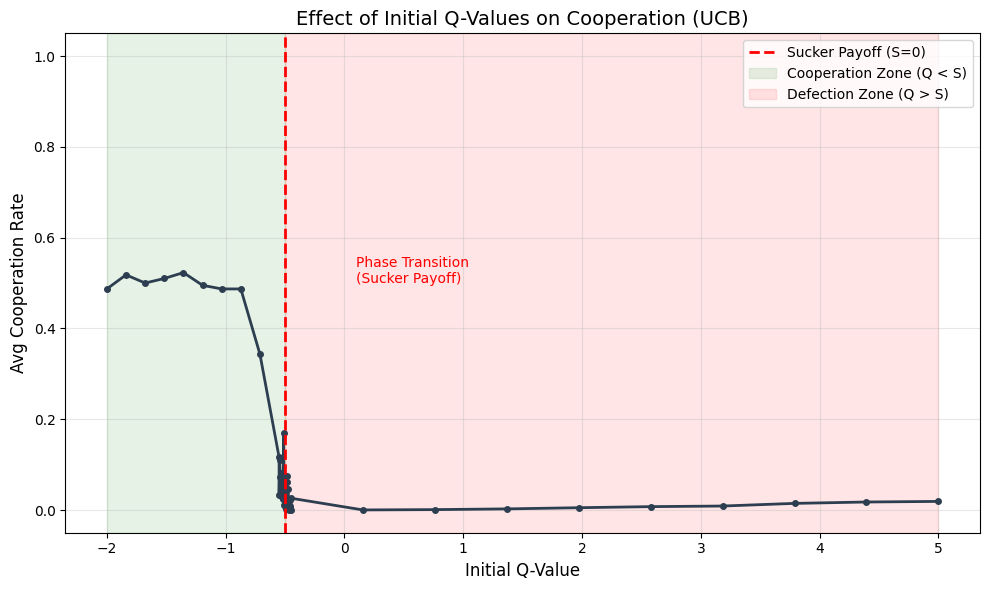

In [4]:
plt.figure(figsize=(10, 6))
plt.plot(initial_q_values, avg_cooperation_rates, marker='o', linestyle='-', color='#2c3e50', linewidth=2, markersize=4)

# Highlight the Sucker Payoff (0)
plt.axvline(x=-0.5, color='r', linestyle='--', linewidth=2, label='Sucker Payoff (S=0)')
plt.text(0.1, 0.5, 'Phase Transition\n(Sucker Payoff)', color='r', fontsize=10)

plt.axvspan(-2, -0.5, color='green', alpha=0.1, label='Cooperation Zone (Q < S)')
plt.axvspan(-0.5, 5, color='red', alpha=0.1, label='Defection Zone (Q > S)')

plt.title("Effect of Initial Q-Values on Cooperation (UCB)", fontsize=14)
plt.xlabel("Initial Q-Value", fontsize=12)
plt.ylabel("Avg Cooperation Rate", fontsize=12)
plt.ylim(-0.05, 1.05)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()